In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [5]:
# Load dataset
data = pd.read_csv(r"C:\Users\pavit\Downloads\letter+recognition\letter-recognition.data", header=None)

# Show first 5 rows
data.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [6]:
columns = ['letter'] + [f'feature_{i}' for i in range(1, 17)]

data.columns = columns

data.head()

,letter,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


In [7]:
X = data.iloc[:, 1:].values
y = data.iloc[:, 0].values

In [12]:
# Convert letters A-Z into numbers
encoder = LabelEncoder()

y = encoder.fit_transform(y)

# Convert into one-hot encoding
y = to_categorical(y)

In [15]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (16000, 16)
Testing Data: (4000, 16)


In [18]:
model = Sequential()

# Input + Hidden Layer 1
model.add(Dense(128, activation='relu', input_shape=(16,)))
model.add(Dropout(0.2))

# Hidden Layer 2
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(26, activation='softmax'))

C:\Users\pavit\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4382 - loss: 1.9411 - val_accuracy: 0.7156 - val_loss: 1.0782
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6730 - loss: 1.0811 - val_accuracy: 0.7741 - val_loss: 0.7928
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7247 - loss: 0.8905 - val_accuracy: 0.8075 - val_loss: 0.6615
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7488 - loss: 0.7934 - val_accuracy: 0.8259 - val_loss: 0.5849
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7719 - loss: 0.7135 - val_accuracy: 0.8419 - val_loss: 0.5322
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.6516 - val_accuracy: 0.8591 - val_loss: 0.4754
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8084 - loss: 0.6057 - val_accuracy: 0.8694 - val_loss: 0.4463
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8194 - loss: 0.5736 - val_accuracy: 0.

In [21]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9355 - loss: 0.2317
Loss : 0.23167116940021515
Accuracy : 0.9355000257492065


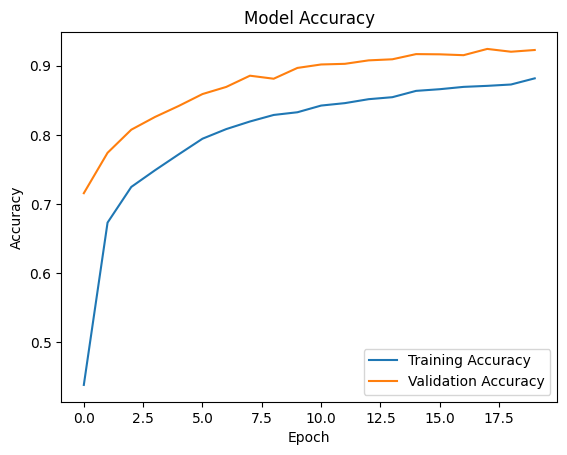

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

In [ ]:
prediction = model.predict(X_test)

predicted_class = np.argmax(prediction[15])

print("Predicted Letter :", encoder.inverse_transform([predicted_class]))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted Letter : [16]
